In [1]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py import discover_petri_net_inductive as inductive_miner
from pm4py.algo.conformance.alignments.petri_net import algorithm as align_factory
from pm4py.visualization.petri_net import visualizer as visualizer
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.objects.conversion.log import converter
import os
import pandas as pd

In [6]:
log_model = xes_importer.apply("teleclaims4model (1).xes")
log_alignment = xes_importer.apply("teleclaims4alignments (1).xes")

parsing log, completed traces :: 100%|██████████| 3512/3512 [00:01<00:00, 1813.10it/s]


In [3]:
pd.set_option('display.max_columns', 13)
pd.set_option('display.width', 110000)
pd.set_option('display.max_rows', 500)

print(converter.apply(log_model, variant=converter.TO_DATA_FRAME))

      lifecycle:transition            time:timestamp          (case)_description call_centre                                    concept:name              org:resource case:concept:name case:variant  case:variant-index    case:creator location duration                     outcome
0                    start 1970-01-01 01:00:00+00:00  Simulated process instance      Sydney                                  incoming claim                  customer                 1    Variant 2                   2  Fluxicon Disco      NaN      NaN                         NaN
1                 complete 1970-01-01 01:00:00+00:00  Simulated process instance      Sydney                                  incoming claim                  customer                 1    Variant 2                   2  Fluxicon Disco      NaN      NaN                         NaN
2                    start 1970-01-01 01:00:00+00:00  Simulated process instance         NaN  S check if sufficient information is available  Call Centre Agent 

### Discover the process model using the inductive miner

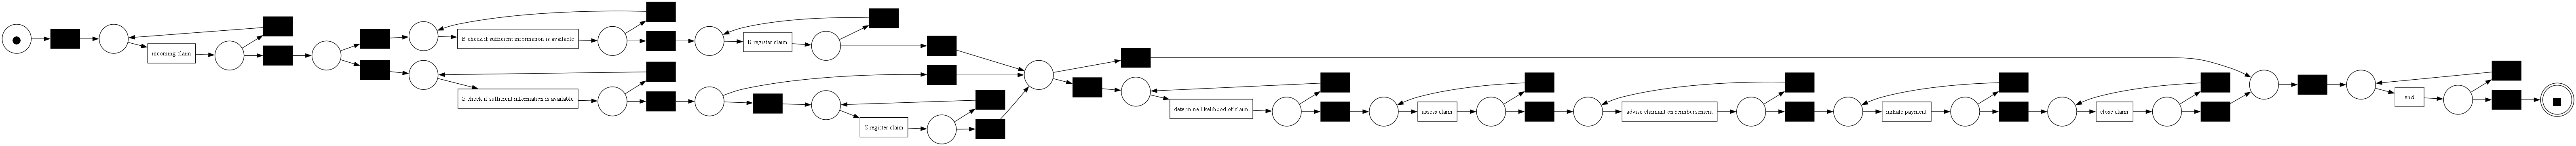

In [5]:
net, initial_marking, final_marking = inductive_miner(log_model)
gviz = visualizer.apply(net, initial_marking, final_marking)
visualizer.view(gviz)

### Compute the alignment


In [7]:
aligned_traces = align_factory.apply(log_alignment, net, initial_marking, final_marking)
fitness = replay_fitness.evaluate(
    aligned_traces,
    variant=replay_fitness.Variants.ALIGNMENT_BASED
)
fitness


aligning log, completed variants :: 100%|██████████| 12/12 [00:00<00:00, 39.56it/s]


{'percFitTraces': 38.752847380410024,
 'averageFitness': 0.9048453444808638,
 'percentage_of_fitting_traces': 38.752847380410024,
 'average_trace_fitness': 0.9048453444808638,
 'log_fitness': 0.9072831305837954}

### What behaviour is documented in the traces that cannot be perfectly aligned with the model?

In [9]:
deviation_counts = {}
for trace in aligned_traces:
    alignment = trace["alignment"]

    deviations = [
        (log_move, model_move)
        for log_move, model_move in alignment
        if log_move != model_move
    ]

    for dev in deviations:
        if dev in deviation_counts:
            deviation_counts[dev] += 1
        else:
            deviation_counts[dev] = 1

for (log_move, model_move), freq in deviation_counts.items():
    print(f"log move: {log_move}, model move: {model_move} -> {freq} times")

log move: >>, model move: None -> 65180 times
log move: determine likelihood of claim, model move: >> -> 978 times
log move: >>, model move: advise claimant on reimbursement -> 1467 times
log move: advise claimant on reimbursement, model move: >> -> 1964 times
log move: >>, model move: initiate payment -> 485 times
log move: >>, model move: close claim -> 485 times
log move: >>, model move: B register claim -> 195 times
